# 1D exact full likelihood: smooth 0.5 vs 1.5 with nugget

This is the nugget version of the simple 1D exact diagnostic.

- true smooth: `0.5`, `1.5`
- fitted smooth: `0.5`, `1.5`
- true nugget: nonzero
- fitted variants:
  - `nugget_free`: estimate `sigmasq`, `range`, `nugget`
  - `nugget0_fit`: estimate `sigmasq`, `range`, with nugget incorrectly fixed to `0`
- sample sizes: `200, 400, 800, 1600, 3200`

No Vecchia. No thinning. Each `n` gets a fresh exact dense 1D Matérn simulation.


In [1]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import gamma as scipy_gamma, kv as scipy_kv
from scipy.linalg import cho_factor, cho_solve

warnings.filterwarnings('ignore', category=RuntimeWarning)

ROUND_DECIMALS = 4
PURE_SPACE_DIR = Path('/Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space')
OUT_DIR = PURE_SPACE_DIR / 'log'
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PREFIX = 'sim_1d_exact_nscale_nuggetfree_s05_s15_050826'

def round_df(df, ndigits=ROUND_DECIMALS):
    out = df.copy()
    for c in out.select_dtypes(include=[np.number]).columns:
        out[c] = out[c].round(ndigits)
    return out


In [2]:
TRUE_SMOOTHS = [0.5, 1.5]
FIT_SMOOTHS = [0.5, 1.5]
FIT_VARIANTS = ['nugget_free', 'nugget0_fit']
N_LIST = [200, 400, 800, 1600, 3200]
N_REPS = 1
SIM_SEED = 20260508

TRUE_PARAMS = {
    'sigmasq': 12.0,
    'range': 0.20,
    'nugget': 2.0,
}

INIT_PARAMS = {
    'sigmasq': 10.0,
    'range': 0.20,
    'nugget': 1.0,
}

BOUNDS = {
    'sigmasq': (1e-4, 500.0),
    'range': (0.005, 2.0),
    'nugget': (1e-6, 100.0),
}

JITTER = 1e-8
MAXITER_BY_N = {200: 100, 400: 90, 800: 70, 1600: 55, 3200: 40}

print('true smooths:', TRUE_SMOOTHS)
print('fit smooths:', FIT_SMOOTHS)
print('fit variants:', FIT_VARIANTS)
print('n list:', N_LIST)
print('true params:', TRUE_PARAMS)


true smooths: [0.5, 1.5]
fit smooths: [0.5, 1.5]
fit variants: ['nugget_free', 'nugget0_fit']
n list: [200, 400, 800, 1600, 3200]
true params: {'sigmasq': 12.0, 'range': 0.2, 'nugget': 2.0}


In [3]:
def matern_corr_1d(dist_over_range, smooth):
    r = np.asarray(dist_over_range, dtype=np.float64)
    nu = float(smooth)
    if np.isclose(nu, 0.5):
        return np.exp(-r)
    z = np.sqrt(2.0 * nu) * r
    safe = np.where(z < 1e-12, 1e-12, z)
    out = (2.0 ** (1.0 - nu) / scipy_gamma(nu)) * (safe ** nu) * scipy_kv(nu, safe)
    out = np.where(z < 1e-12, 1.0, out)
    return np.nan_to_num(out, nan=0.0, posinf=1.0, neginf=0.0)


def make_distance_matrix(n):
    x = np.linspace(0.0, 1.0, int(n))
    return x, np.abs(x[:, None] - x[None, :])


def cov_from_dist(dist, smooth, sigmasq, range_, nugget=0.0):
    K = float(sigmasq) * matern_corr_1d(dist / float(range_), smooth)
    if float(nugget) != 0.0:
        K = K + float(nugget) * np.eye(dist.shape[0])
    return K


def simulate_exact(rng, dist, smooth):
    K = cov_from_dist(
        dist,
        smooth,
        TRUE_PARAMS['sigmasq'],
        TRUE_PARAMS['range'],
        TRUE_PARAMS['nugget'],
    )
    K = K + JITTER * np.eye(dist.shape[0])
    L = np.linalg.cholesky(K)
    return L @ rng.standard_normal(dist.shape[0])


def nll(y, dist, fit_smooth, sigmasq, range_, nugget):
    n = len(y)
    K = cov_from_dist(dist, fit_smooth, sigmasq, range_, nugget)
    K = K + JITTER * np.eye(n)
    try:
        cf = cho_factor(K, lower=True, check_finite=False)
        alpha = cho_solve(cf, y, check_finite=False)
        logdet = 2.0 * np.sum(np.log(np.diag(cf[0])))
        return 0.5 * (logdet + float(y @ alpha) + n * np.log(2.0 * np.pi))
    except Exception:
        return np.inf


def fit_exact(y, dist, fit_smooth, variant, init=None, maxiter=60):
    init = dict(INIT_PARAMS if init is None else init)

    if variant == 'nugget_free':
        theta0 = np.log([init['sigmasq'], init['range'], max(init.get('nugget', INIT_PARAMS['nugget']), BOUNDS['nugget'][0])])
        bounds = [
            (np.log(BOUNDS['sigmasq'][0]), np.log(BOUNDS['sigmasq'][1])),
            (np.log(BOUNDS['range'][0]), np.log(BOUNDS['range'][1])),
            (np.log(BOUNDS['nugget'][0]), np.log(BOUNDS['nugget'][1])),
        ]

        def obj(theta):
            sigmasq, range_, nugget = np.exp(theta)
            return nll(y, dist, fit_smooth, sigmasq, range_, nugget)

        opt = minimize(obj, theta0, method='L-BFGS-B', bounds=bounds,
                       options={'maxiter': int(maxiter), 'ftol': 1e-8, 'maxls': 30})
        sigmasq_hat, range_hat, nugget_hat = np.exp(opt.x)
    elif variant == 'nugget0_fit':
        theta0 = np.log([init['sigmasq'], init['range']])
        bounds = [
            (np.log(BOUNDS['sigmasq'][0]), np.log(BOUNDS['sigmasq'][1])),
            (np.log(BOUNDS['range'][0]), np.log(BOUNDS['range'][1])),
        ]

        def obj(theta):
            sigmasq, range_ = np.exp(theta)
            return nll(y, dist, fit_smooth, sigmasq, range_, 0.0)

        opt = minimize(obj, theta0, method='L-BFGS-B', bounds=bounds,
                       options={'maxiter': int(maxiter), 'ftol': 1e-8, 'maxls': 30})
        sigmasq_hat, range_hat = np.exp(opt.x)
        nugget_hat = 0.0
    else:
        raise ValueError(f'unknown variant: {variant}')

    return {
        'sigmasq': float(sigmasq_hat),
        'range': float(range_hat),
        'nugget': float(nugget_hat),
        'loss_per_obs': float(opt.fun) / len(y),
        'success': bool(opt.success),
        'message': str(opt.message),
        'n_iter': int(getattr(opt, 'nit', -1)),
        'n_eval': int(getattr(opt, 'nfev', -1)),
    }


def microergodic(sigmasq, range_, smooth):
    sigmasq = np.asarray(sigmasq, dtype=float)
    range_ = np.asarray(range_, dtype=float)
    smooth = np.asarray(smooth, dtype=float)
    return sigmasq / (range_ ** (2.0 * smooth))


In [4]:
# Simulate fresh data for each n and true smooth.
rng = np.random.default_rng(SIM_SEED)
dist_cache = {}
sim_data = {}
sim_rows = []

for n in N_LIST:
    _, dist = make_distance_matrix(n)
    dist_cache[int(n)] = dist
    for true_smooth in TRUE_SMOOTHS:
        for rep in range(N_REPS):
            y = simulate_exact(rng, dist, true_smooth)
            sim_data[(int(n), float(true_smooth), int(rep))] = y
            sim_rows.append({
                'n': int(n),
                'true_smooth': float(true_smooth),
                'rep': int(rep),
                'y_mean': float(np.mean(y)),
                'y_var': float(np.var(y, ddof=1)),
            })

sim_df = pd.DataFrame(sim_rows)
sim_path = OUT_DIR / f'{OUT_PREFIX}_sim_summary.csv'
round_df(sim_df).to_csv(sim_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
print('Saved simulation summary:', sim_path)
display(round_df(sim_df))


Saved simulation summary: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/sim_1d_exact_nscale_nuggetfree_s05_s15_050826_sim_summary.csv


,n,true_smooth,rep,y_mean,y_var
0,200,0.5,0,-0.8581,13.0094
1,200,1.5,0,-0.1780,3.5933
2,400,0.5,0,-3.6870,8.3042
3,400,1.5,0,0.1777,5.5945
4,800,0.5,0,1.0144,5.9334
5,800,1.5,0,0.0209,10.2211
6,1600,0.5,0,-4.2541,10.1059
7,1600,1.5,0,4.6761,8.6956
8,3200,0.5,0,0.8184,7.7950
9,3200,1.5,0,2.8349,9.3140


In [5]:
# Exact dense full likelihood fits.
rows = []
t_all = time.time()

for true_smooth in TRUE_SMOOTHS:
    for fit_smooth in FIT_SMOOTHS:
        for variant in FIT_VARIANTS:
            for rep in range(N_REPS):
                warm = None
                for n in N_LIST:
                    y = sim_data[(int(n), float(true_smooth), int(rep))]
                    dist = dist_cache[int(n)]
                    maxiter = MAXITER_BY_N.get(int(n), 50)
                    t0 = time.time()
                    est = fit_exact(y, dist, fit_smooth, variant, init=warm, maxiter=maxiter)
                    fit_s = time.time() - t0
                    warm = {'sigmasq': est['sigmasq'], 'range': est['range'], 'nugget': max(est['nugget'], INIT_PARAMS['nugget'])}
                    row = {
                        'n': int(n),
                        'true_smooth': float(true_smooth),
                        'fit_smooth': float(fit_smooth),
                        'variant': variant,
                        'rep': int(rep),
                        'loss_per_obs': est['loss_per_obs'],
                        'success': est['success'],
                        'message': est['message'],
                        'n_iter': est['n_iter'],
                        'n_eval': est['n_eval'],
                        'fit_s': float(fit_s),
                        'est_sigmasq': est['sigmasq'],
                        'est_range': est['range'],
                        'est_nugget': est['nugget'],
                        'true_sigmasq': TRUE_PARAMS['sigmasq'],
                        'true_range': TRUE_PARAMS['range'],
                        'true_nugget': TRUE_PARAMS['nugget'],
                    }
                    rows.append(row)
                    tmp = pd.DataFrame(rows)
                    round_df(tmp).to_csv(OUT_DIR / f'{OUT_PREFIX}_fits_partial.csv', index=False, float_format=f'%.{ROUND_DECIMALS}f')
                    print(
                        f"{variant} | true={true_smooth}, fit={fit_smooth}, n={n}: "
                        f"sigmasq={est['sigmasq']:.4f}, range={est['range']:.4f}, nugget={est['nugget']:.4f}, "
                        f"loss={est['loss_per_obs']:.4f}, time={fit_s:.1f}s, success={est['success']}"
                    )

fit_df = pd.DataFrame(rows)
fit_df['est_microergodic_fitnu'] = microergodic(fit_df['est_sigmasq'], fit_df['est_range'], fit_df['fit_smooth'])
fit_df['true_microergodic_fitnu'] = microergodic(TRUE_PARAMS['sigmasq'], TRUE_PARAMS['range'], fit_df['fit_smooth'])
fit_df['true_microergodic_truenu'] = microergodic(TRUE_PARAMS['sigmasq'], TRUE_PARAMS['range'], fit_df['true_smooth'])

fit_path = OUT_DIR / f'{OUT_PREFIX}_fits.csv'
round_df(fit_df).to_csv(fit_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
print('Saved fits:', fit_path)
print('Total elapsed:', time.time() - t_all)
display(round_df(fit_df))


nugget_free | true=0.5, fit=0.5, n=200: sigmasq=15.3044, range=0.3122, nugget=2.1277, loss=2.0320, time=0.1s, success=True
nugget_free | true=0.5, fit=0.5, n=400: sigmasq=16.7800, range=0.4300, nugget=2.1178, loss=1.9458, time=0.2s, success=True
nugget_free | true=0.5, fit=0.5, n=800: sigmasq=5.2318, range=0.0922, nugget=1.7207, loss=1.8279, time=1.1s, success=True
nugget_free | true=0.5, fit=0.5, n=1600: sigmasq=20.5752, range=0.3305, nugget=1.9981, loss=1.8636, time=7.2s, success=True
nugget_free | true=0.5, fit=0.5, n=3200: sigmasq=7.0587, range=0.1440, nugget=2.0211, loss=1.8317, time=15.8s, success=True
nugget0_fit | true=0.5, fit=0.5, n=200: sigmasq=13.9025, range=0.0285, nugget=0.0000, loss=2.1311, time=0.1s, success=True
nugget0_fit | true=0.5, fit=0.5, n=400: sigmasq=21.6495, range=0.0265, nugget=0.0000, loss=2.0801, time=0.1s, success=True
nugget0_fit | true=0.5, fit=0.5, n=800: sigmasq=8.0608, range=0.0050, nugget=0.0000, loss=1.9971, time=0.4s, success=True
nugget0_fit | tr

,n,true_smooth,fit_smooth,variant,rep,loss_per_obs,success,message,n_iter,n_eval,fit_s,est_sigmasq,est_range,est_nugget,true_sigmasq,true_range,true_nugget,est_microergodic_fitnu,true_microergodic_fitnu,true_microergodic_truenu
0,200,0.5,0.5,nugget_free,0,2.0320,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,12,56,0.0957,15.3044,0.3122,2.1277,12.0,0.2,2.0,4.902370e+01,60.0,60.0
1,400,0.5,0.5,nugget_free,0,1.9458,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,10,52,0.2088,16.7800,0.4300,2.1178,12.0,0.2,2.0,3.901950e+01,60.0,60.0
2,800,0.5,0.5,nugget_free,0,1.8279,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,12,76,1.0510,5.2318,0.0922,1.7207,12.0,0.2,2.0,5.672370e+01,60.0,60.0
3,1600,0.5,0.5,nugget_free,0,1.8636,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,14,64,7.2147,20.5752,0.3305,1.9981,12.0,0.2,2.0,6.225810e+01,60.0,60.0
4,3200,0.5,0.5,nugget_free,0,1.8317,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,13,64,15.7651,7.0587,0.1440,2.0211,12.0,0.2,2.0,4.902130e+01,60.0,60.0
5,200,0.5,0.5,nugget0_fit,0,2.1311,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,10,45,0.0623,13.9025,0.0285,0.0000,12.0,0.2,2.0,4.875834e+02,60.0,60.0
6,400,0.5,0.5,nugget0_fit,0,2.0801,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,10,36,0.0773,21.6495,0.0265,0.0000,12.0,0.2,2.0,8.180642e+02,60.0,60.0
7,800,0.5,0.5,nugget0_fit,0,1.9971,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,8,42,0.4033,8.0608,0.0050,0.0000,12.0,0.2,2.0,1.612161e+03,60.0,60.0
8,1600,0.5,0.5,nugget0_fit,0,2.0967,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,9,33,1.3825,28.0117,0.0084,0.0000,12.0,0.2,2.0,3.333068e+03,60.0,60.0
9,3200,0.5,0.5,nugget0_fit,0,2.1013,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,9,36,6.9093,33.2861,0.0050,0.0000,12.0,0.2,2.0,6.657212e+03,60.0,60.0


In [6]:
summary_df = (
    fit_df
    .groupby(['variant', 'true_smooth', 'fit_smooth', 'n'], observed=False)
    .agg(
        loss_mean=('loss_per_obs', 'mean'),
        sigmasq_mean=('est_sigmasq', 'mean'),
        sigmasq_sd=('est_sigmasq', 'std'),
        range_mean=('est_range', 'mean'),
        range_sd=('est_range', 'std'),
        nugget_mean=('est_nugget', 'mean'),
        nugget_sd=('est_nugget', 'std'),
        micro_mean=('est_microergodic_fitnu', 'mean'),
        success_rate=('success', 'mean'),
        fit_s_mean=('fit_s', 'mean'),
    )
    .reset_index()
)
summary_path = OUT_DIR / f'{OUT_PREFIX}_summary.csv'
round_df(summary_df).to_csv(summary_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
print('Saved summary:', summary_path)
display(round_df(summary_df))


Saved summary: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/sim_1d_exact_nscale_nuggetfree_s05_s15_050826_summary.csv


,variant,true_smooth,fit_smooth,n,loss_mean,sigmasq_mean,sigmasq_sd,range_mean,range_sd,nugget_mean,nugget_sd,micro_mean,success_rate,fit_s_mean
0,nugget0_fit,0.5,0.5,200,2.1311,13.9025,NaN,0.0285,NaN,0.0000,NaN,4.875834e+02,1.0,0.0623
1,nugget0_fit,0.5,0.5,400,2.0801,21.6495,NaN,0.0265,NaN,0.0000,NaN,8.180642e+02,1.0,0.0773
2,nugget0_fit,0.5,0.5,800,1.9971,8.0608,NaN,0.0050,NaN,0.0000,NaN,1.612161e+03,1.0,0.4033
3,nugget0_fit,0.5,0.5,1600,2.0967,28.0117,NaN,0.0084,NaN,0.0000,NaN,3.333068e+03,1.0,1.3825
4,nugget0_fit,0.5,0.5,3200,2.1013,33.2861,NaN,0.0050,NaN,0.0000,NaN,6.657212e+03,1.0,6.9093
5,nugget0_fit,0.5,1.5,200,2.2655,11.6486,NaN,0.0080,NaN,0.0000,NaN,2.243832e+07,1.0,0.6473
6,nugget0_fit,0.5,1.5,400,2.2940,17.0325,NaN,0.0050,NaN,0.0000,NaN,1.362604e+08,1.0,0.4865
7,nugget0_fit,0.5,1.5,800,2.4399,86.5501,NaN,0.0050,NaN,0.0000,NaN,6.924010e+08,1.0,1.4641
8,nugget0_fit,0.5,1.5,1600,2.6693,500.0000,NaN,0.0050,NaN,0.0000,NaN,4.000000e+09,1.0,1.3056
9,nugget0_fit,0.5,1.5,3200,6.9206,500.0000,NaN,0.0050,NaN,0.0000,NaN,4.000000e+09,1.0,2.3153


Saved parameter plot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/sim_1d_exact_nscale_nuggetfree_s05_s15_050826_nugget_free_param_trajectories.png


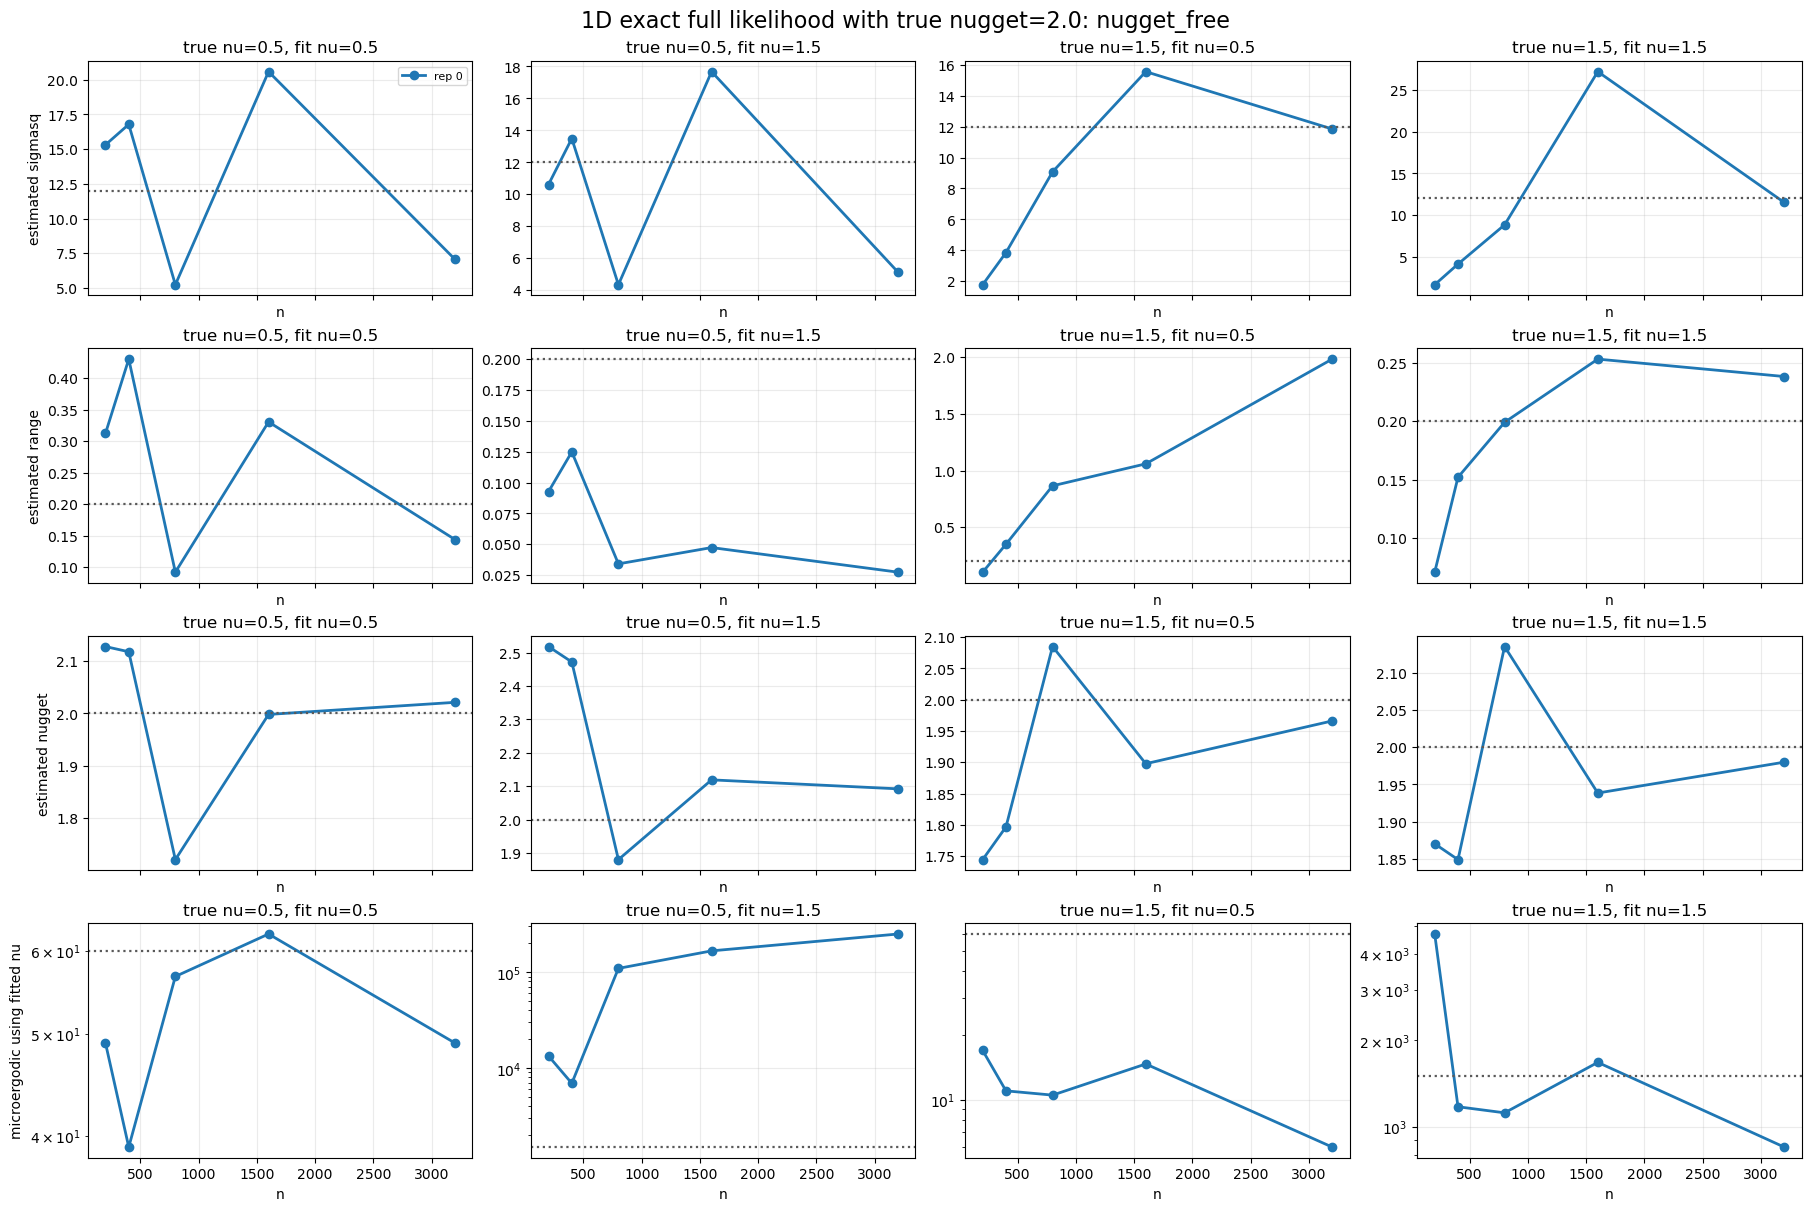

Saved parameter plot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/sim_1d_exact_nscale_nuggetfree_s05_s15_050826_nugget0_fit_param_trajectories.png


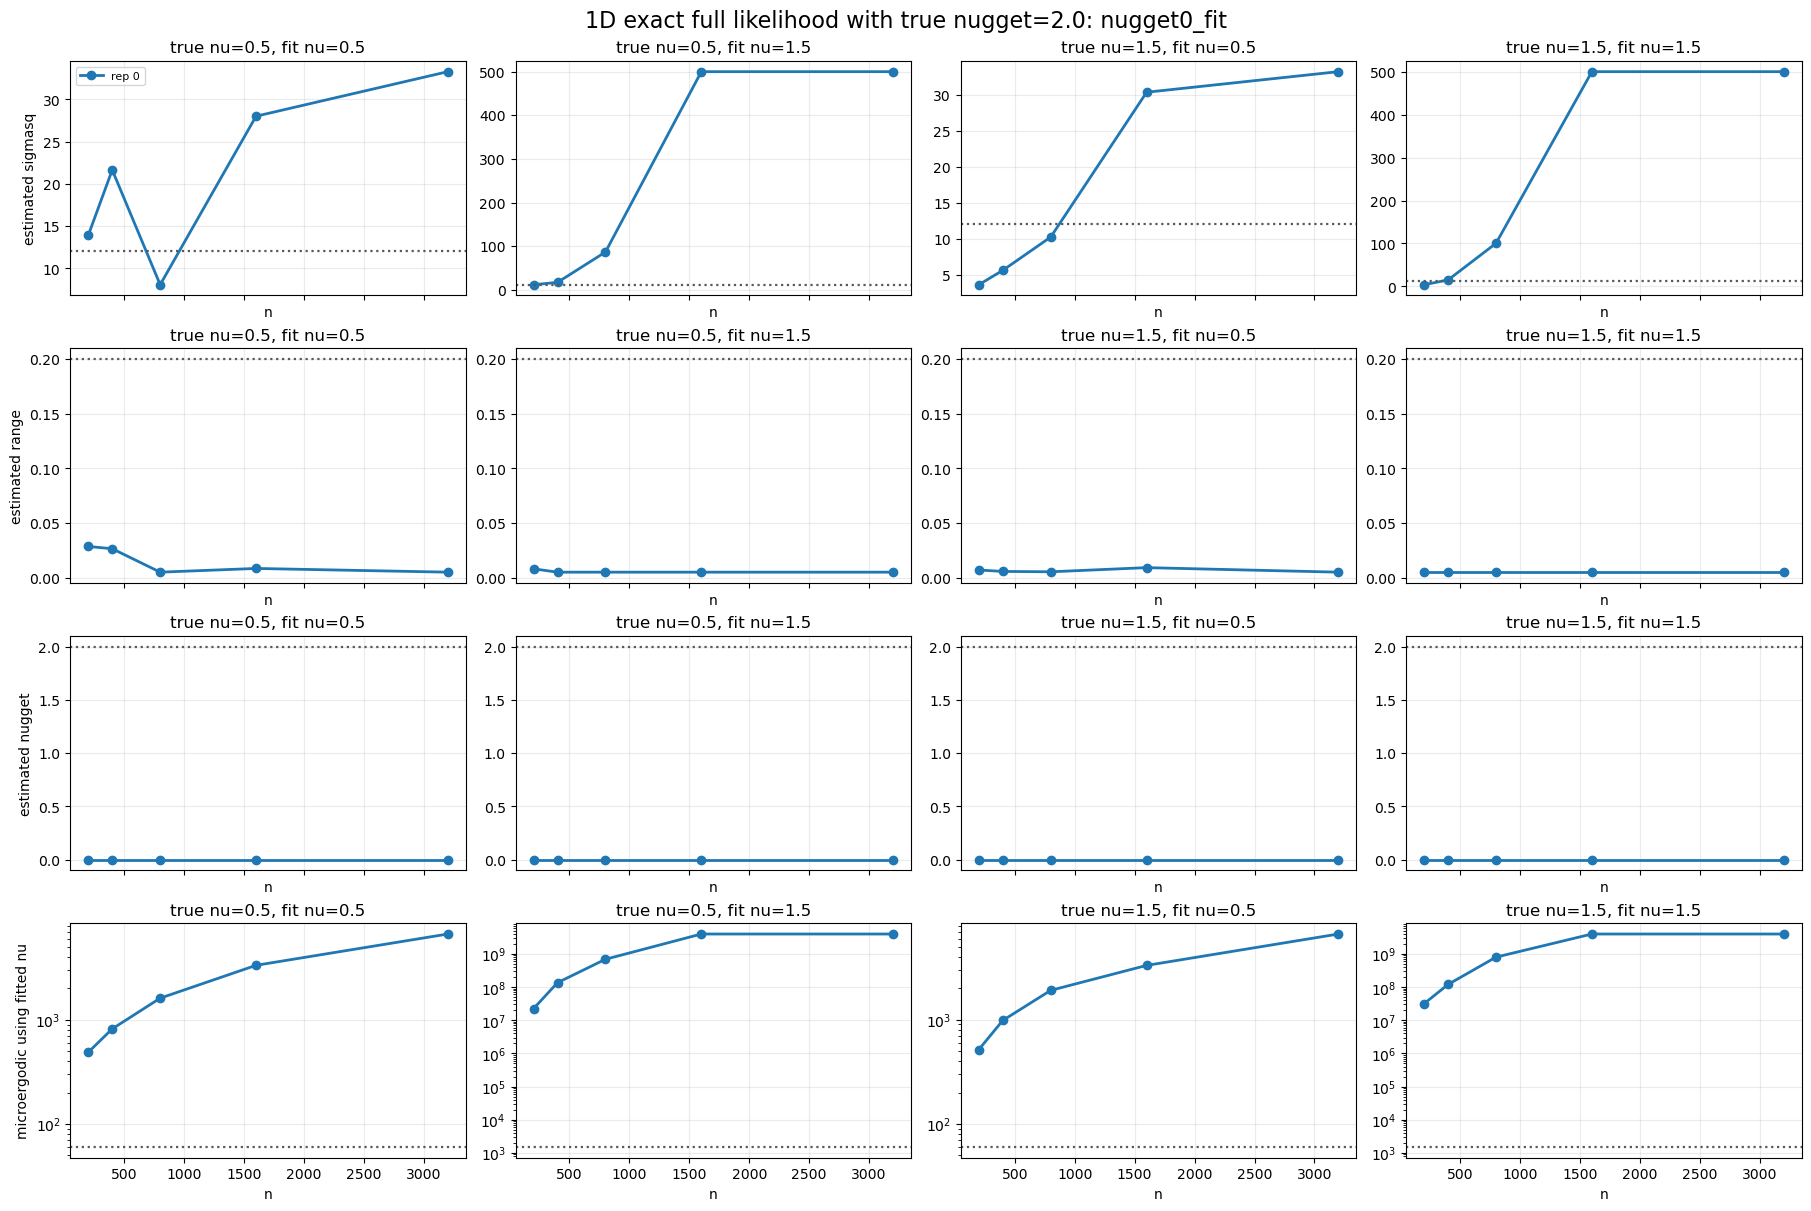

In [7]:
# Parameter trajectories. Rows are parameters, columns are true/fit smooth combinations.
combo_order = [(0.5, 0.5), (0.5, 1.5), (1.5, 0.5), (1.5, 1.5)]
params = [
    ('est_sigmasq', 'estimated sigmasq', TRUE_PARAMS['sigmasq']),
    ('est_range', 'estimated range', TRUE_PARAMS['range']),
    ('est_nugget', 'estimated nugget', TRUE_PARAMS['nugget']),
    ('est_microergodic_fitnu', 'microergodic using fitted nu', None),
]

for variant in FIT_VARIANTS:
    sub_variant = fit_df[fit_df['variant'] == variant].copy()
    fig, axes = plt.subplots(len(params), len(combo_order), figsize=(18, 12), constrained_layout=True, sharex=True)
    for col, (true_smooth, fit_smooth) in enumerate(combo_order):
        sub = sub_variant[(sub_variant['true_smooth'] == true_smooth) & (sub_variant['fit_smooth'] == fit_smooth)].copy()
        sub = sub.sort_values('n')
        for row_idx, (param, ylabel, true_val) in enumerate(params):
            ax = axes[row_idx, col]
            for rep, rep_df in sub.groupby('rep'):
                ax.plot(rep_df['n'], rep_df[param], marker='o', linewidth=2, label=f'rep {rep}')
            if true_val is not None:
                ax.axhline(true_val, color='0.35', linestyle=':', linewidth=1.6)
            if param == 'est_microergodic_fitnu':
                true_micro = microergodic(TRUE_PARAMS['sigmasq'], TRUE_PARAMS['range'], fit_smooth)
                ax.axhline(true_micro, color='0.35', linestyle=':', linewidth=1.6)
                ax.set_yscale('log')
            ax.set_title(f'true nu={true_smooth}, fit nu={fit_smooth}')
            ax.set_xlabel('n')
            if col == 0:
                ax.set_ylabel(ylabel)
            ax.grid(True, alpha=0.25)
    axes[0, 0].legend(fontsize=8)
    fig.suptitle(f'1D exact full likelihood with true nugget={TRUE_PARAMS["nugget"]}: {variant}', fontsize=16)
    plot_path = OUT_DIR / f'{OUT_PREFIX}_{variant}_param_trajectories.png'
    fig.savefig(plot_path, dpi=180, bbox_inches='tight')
    print('Saved parameter plot:', plot_path)
    plt.show()


Saved loss comparison: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/sim_1d_exact_nscale_nuggetfree_s05_s15_050826_loss_comparison.png


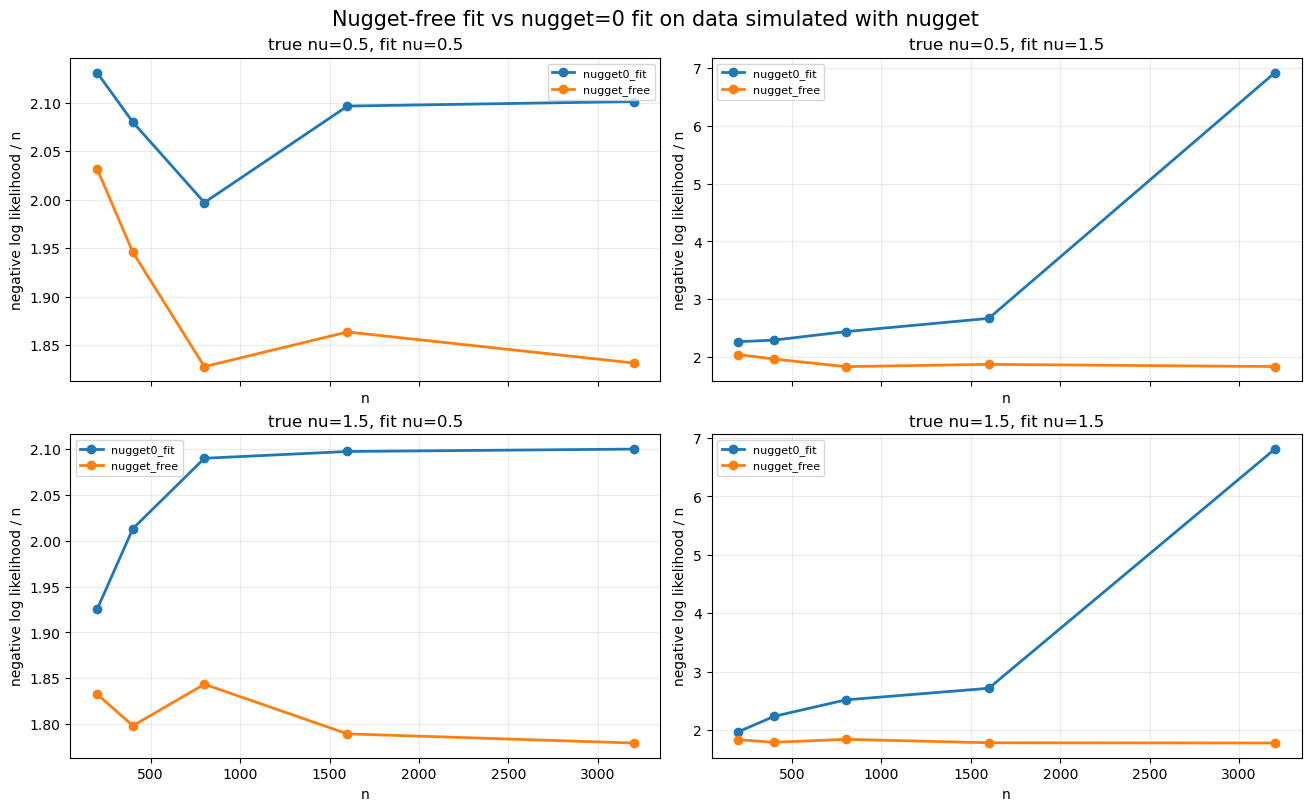

In [8]:
# Direct loss comparison: lower is better.
fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True, sharex=True)
for ax, (true_smooth, fit_smooth) in zip(axes.ravel(), combo_order):
    sub = fit_df[(fit_df['true_smooth'] == true_smooth) & (fit_df['fit_smooth'] == fit_smooth)].copy()
    for variant, vdf in sub.groupby('variant'):
        vdf = vdf.sort_values('n')
        ax.plot(vdf['n'], vdf['loss_per_obs'], marker='o', linewidth=2, label=variant)
    ax.set_title(f'true nu={true_smooth}, fit nu={fit_smooth}')
    ax.set_xlabel('n')
    ax.set_ylabel('negative log likelihood / n')
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)
fig.suptitle('Nugget-free fit vs nugget=0 fit on data simulated with nugget', fontsize=15)
loss_plot_path = OUT_DIR / f'{OUT_PREFIX}_loss_comparison.png'
fig.savefig(loss_plot_path, dpi=180, bbox_inches='tight')
print('Saved loss comparison:', loss_plot_path)
plt.show()
